### Nome: Tiago Oliveira Lima

### Matrícula: 564988

# Questão 1

## Questão A

O item abaixo implementa o K-medias com distancia Euclidiana do inicio. O NumPy e usado apenas para manipulacao numerica dos vetores, normalizacao e calculos de distancia; o algoritmo de agrupamento e o indice Davies-Bouldin sao implementados manualmente.

In [32]:
import numpy as np

import matplotlib.pyplot as plt

In [33]:
dados_originais = np.loadtxt('quake.csv', delimiter=',')

medias = dados_originais.mean(axis=0)
desvios = dados_originais.std(axis=0)
desvios[desvios == 0] = 1.0
dados = (dados_originais - medias) / desvios

dados.shape, dados[:3]

((2178, 2),
 array([[-1.97199797, -0.22393957],
        [ 1.23018213,  0.80788009],
        [ 1.10967878,  0.73930527]]))

In [34]:
def distancias_quadraticas(pontos, centroides):
    diferencas = pontos[:, np.newaxis, :] - centroides[np.newaxis, :, :]
    return np.sum(diferencas ** 2, axis=2)


def atribuir_grupos(dados, centroides):
    distancias = distancias_quadraticas(dados, centroides)
    grupos = np.argmin(distancias, axis=1)
    erro = np.sum(distancias[np.arange(len(dados)), grupos])
    return grupos, erro


def recalcular_centroides(dados, grupos, k):
    centroides = np.empty((k, dados.shape[1]))

    for grupo in range(k):
        pontos_grupo = dados[grupos == grupo]
        if len(pontos_grupo) == 0:
            centroides[grupo] = dados[np.random.randint(len(dados))]
        else:
            centroides[grupo] = pontos_grupo.mean(axis=0)

    return centroides


def k_medias(dados, k, max_iter=100, tolerancia=1e-6):
    indices_iniciais = np.random.choice(len(dados), size=k, replace=False)
    centroides = dados[indices_iniciais].copy()
    grupos = None

    for _ in range(max_iter):
        novos_grupos, erro = atribuir_grupos(dados, centroides)
        novos_centroides = recalcular_centroides(dados, novos_grupos, k)
        deslocamento = np.max(np.sum((centroides - novos_centroides) ** 2, axis=1))

        if grupos is not None and np.array_equal(novos_grupos, grupos):
            return novos_grupos, novos_centroides, erro
        if deslocamento < tolerancia:
            return novos_grupos, novos_centroides, erro

        grupos = novos_grupos
        centroides = novos_centroides

    grupos, erro = atribuir_grupos(dados, centroides)
    return grupos, centroides, erro


def melhor_k_medias(dados, k, repeticoes=20):
    melhor = None
    for _ in range(repeticoes):
        resultado = k_medias(dados, k)
        if melhor is None or resultado[2] < melhor[2]:
            melhor = resultado
    return melhor

In [35]:
def indice_davies_bouldin(dados, grupos, centroides):
    k = len(centroides)
    dispersoes = np.zeros(k)

    for grupo in range(k):
        pontos_grupo = dados[grupos == grupo]
        if len(pontos_grupo) > 0:
            distancias = np.sqrt(np.sum((pontos_grupo - centroides[grupo]) ** 2, axis=1))
            dispersoes[grupo] = distancias.mean()

    similaridades_maximas = np.zeros(k)
    for i in range(k):
        maior = -np.inf
        for j in range(k):
            if i == j:
                continue
            distancia_centroides = np.sqrt(np.sum((centroides[i] - centroides[j]) ** 2))
            similaridade = np.inf if distancia_centroides == 0 else (dispersoes[i] + dispersoes[j]) / distancia_centroides
            if similaridade > maior:
                maior = similaridade
        similaridades_maximas[i] = maior

    return similaridades_maximas.mean()

In [36]:
np.random.seed(42)

avaliacoes = []
for k in range(4, 21):
    grupos, centroides, erro = melhor_k_medias(dados, k, repeticoes=20)
    db = indice_davies_bouldin(dados, grupos, centroides)
    avaliacoes.append({
        'k': k,
        'grupos': grupos,
        'centroides': centroides,
        'erro': erro,
        'db': db,
    })

melhor_resultado = min(avaliacoes, key=lambda item: item['db'])

print('Resultados por k:')
for item in avaliacoes:
    print(f"k={item['k']:2d} | DB={item['db']:.4f} | erro={item['erro']:.4f}")

print(f"\nMelhor k pelo indice DB: {melhor_resultado['k']} (DB={melhor_resultado['db']:.4f})")

Resultados por k:
k= 4 | DB=0.6140 | erro=723.9399
k= 5 | DB=0.6193 | erro=585.5583
k= 6 | DB=0.6197 | erro=471.1877
k= 7 | DB=0.6342 | erro=385.9112
k= 8 | DB=0.6954 | erro=320.3763
k= 9 | DB=0.6517 | erro=256.1109
k=10 | DB=0.6658 | erro=225.9826
k=11 | DB=0.6249 | erro=181.5568
k=12 | DB=0.6498 | erro=167.0440
k=13 | DB=0.6487 | erro=141.9082
k=14 | DB=0.6619 | erro=127.5221
k=15 | DB=0.6460 | erro=117.4128
k=16 | DB=0.6440 | erro=110.0140
k=17 | DB=0.6012 | erro=106.6140
k=18 | DB=0.5960 | erro=90.6777
k=19 | DB=0.6115 | erro=89.6431
k=20 | DB=0.6137 | erro=87.0598

Melhor k pelo indice DB: 18 (DB=0.5960)


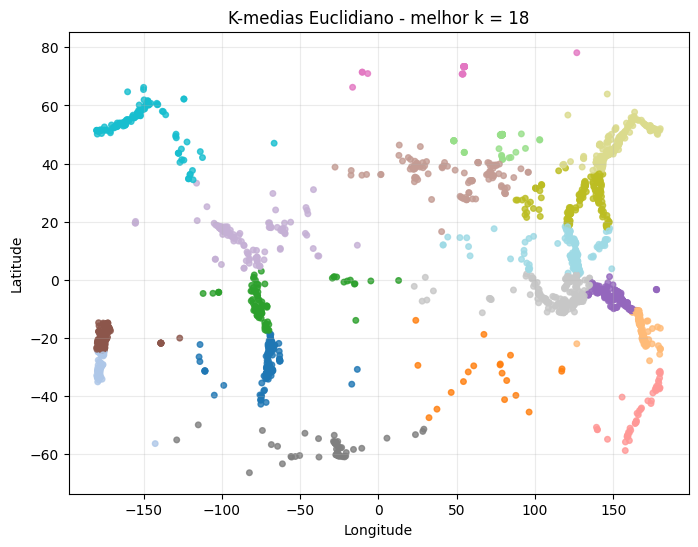

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(
    dados_originais[:, 1],
    dados_originais[:, 0],
    c=melhor_resultado['grupos'],
    cmap='tab20',
    s=16,
    alpha=0.8,
)
plt.title(f"K-medias Euclidiano - melhor k = {melhor_resultado['k']}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(alpha=0.25)
plt.show()

## Questão B

In [38]:
covariancia = np.cov(dados, rowvar=False)
covariancia_inv = np.linalg.pinv(covariancia)


def distancias_mahalanobis_quadraticas(pontos, centroides, matriz_inv):
    diferencas = pontos[:, np.newaxis, :] - centroides[np.newaxis, :, :]
    return np.einsum('nkd,df,nkf->nk', diferencas, matriz_inv, diferencas)


def distancia_mahalanobis(a, b, matriz_inv):
    diferenca = a - b
    return np.sqrt(diferenca @ matriz_inv @ diferenca)

In [39]:
def atribuir_grupos_mahalanobis(dados, centroides, matriz_inv):
    distancias = distancias_mahalanobis_quadraticas(dados, centroides, matriz_inv)
    grupos = np.argmin(distancias, axis=1)
    erro = np.sum(distancias[np.arange(len(dados)), grupos])
    return grupos, erro


def k_medias_mahalanobis(dados, k, matriz_inv, max_iter=100, tolerancia=1e-6):
    indices_iniciais = np.random.choice(len(dados), size=k, replace=False)
    centroides = dados[indices_iniciais].copy()
    grupos = None

    for _ in range(max_iter):
        novos_grupos, erro = atribuir_grupos_mahalanobis(dados, centroides, matriz_inv)
        novos_centroides = recalcular_centroides(dados, novos_grupos, k)
        deslocamentos = np.array([
            distancia_mahalanobis(centroides[i], novos_centroides[i], matriz_inv) ** 2
            for i in range(k)
        ])

        if grupos is not None and np.array_equal(novos_grupos, grupos):
            return novos_grupos, novos_centroides, erro
        if deslocamentos.max() < tolerancia:
            return novos_grupos, novos_centroides, erro

        grupos = novos_grupos
        centroides = novos_centroides

    grupos, erro = atribuir_grupos_mahalanobis(dados, centroides, matriz_inv)
    return grupos, centroides, erro


def melhor_k_medias_mahalanobis(dados, k, matriz_inv, repeticoes=20):
    melhor = None
    for _ in range(repeticoes):
        resultado = k_medias_mahalanobis(dados, k, matriz_inv)
        if melhor is None or resultado[2] < melhor[2]:
            melhor = resultado
    return melhor

In [40]:
def indice_davies_bouldin_mahalanobis(dados, grupos, centroides, matriz_inv):
    k = len(centroides)
    dispersoes = np.zeros(k)

    for grupo in range(k):
        pontos_grupo = dados[grupos == grupo]
        if len(pontos_grupo) > 0:
            distancias = np.sqrt(distancias_mahalanobis_quadraticas(pontos_grupo, centroides[grupo:grupo + 1], matriz_inv)[:, 0])
            dispersoes[grupo] = distancias.mean()

    similaridades_maximas = np.zeros(k)
    for i in range(k):
        maior = -np.inf
        for j in range(k):
            if i == j:
                continue

            distancia_centroides = distancia_mahalanobis(centroides[i], centroides[j], matriz_inv)
            similaridade = np.inf if distancia_centroides == 0 else (dispersoes[i] + dispersoes[j]) / distancia_centroides
            if similaridade > maior:
                maior = similaridade

        similaridades_maximas[i] = maior

    return similaridades_maximas.mean()

In [41]:
np.random.seed(42)

avaliacoes_mahalanobis = []
for k in range(4, 21):
    grupos, centroides, erro = melhor_k_medias_mahalanobis(dados, k, covariancia_inv, repeticoes=20)
    db = indice_davies_bouldin_mahalanobis(dados, grupos, centroides, covariancia_inv)
    avaliacoes_mahalanobis.append({
        'k': k,
        'grupos': grupos,
        'centroides': centroides,
        'erro': erro,
        'db': db,
    })

melhor_resultado_mahalanobis = min(avaliacoes_mahalanobis, key=lambda item: item['db'])

print('Resultados por k com distancia de Mahalanobis:')
for item in avaliacoes_mahalanobis:
    print(f"k={item['k']:2d} | DB={item['db']:.4f} | erro={item['erro']:.4f}")

print(f"\nMelhor k pelo indice DB com Mahalanobis: {melhor_resultado_mahalanobis['k']} (DB={melhor_resultado_mahalanobis['db']:.4f})")

Resultados por k com distancia de Mahalanobis:
k= 4 | DB=0.5887 | erro=761.7154
k= 5 | DB=0.6588 | erro=612.0903
k= 6 | DB=0.6231 | erro=485.8852
k= 7 | DB=0.6210 | erro=397.5042
k= 8 | DB=0.6861 | erro=329.2700
k= 9 | DB=0.6540 | erro=266.5976
k=10 | DB=0.6485 | erro=233.4005
k=11 | DB=0.6128 | erro=185.1827
k=12 | DB=0.6422 | erro=163.8953
k=13 | DB=0.5951 | erro=144.7010
k=14 | DB=0.6571 | erro=130.2753
k=15 | DB=0.6410 | erro=118.8788
k=16 | DB=0.6483 | erro=111.8653
k=17 | DB=0.6256 | erro=106.5201
k=18 | DB=0.5918 | erro=91.1176
k=19 | DB=0.6249 | erro=91.3746
k=20 | DB=0.6220 | erro=90.3594

Melhor k pelo indice DB com Mahalanobis: 4 (DB=0.5887)


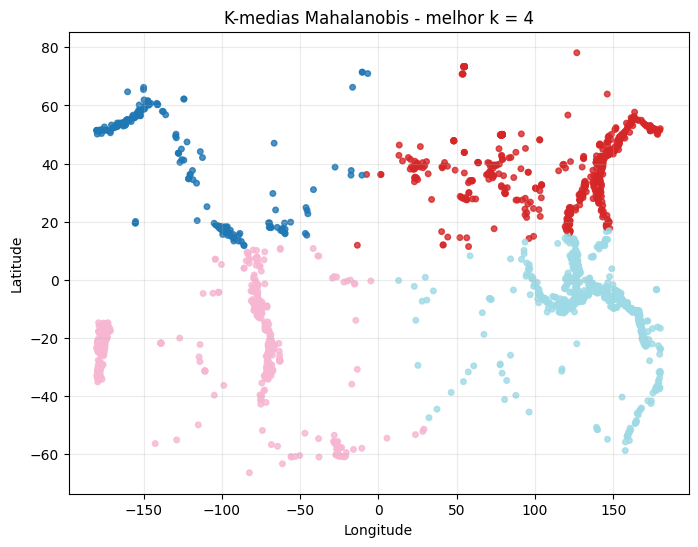

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(
    dados_originais[:, 1],
    dados_originais[:, 0],
    c=melhor_resultado_mahalanobis['grupos'],
    cmap='tab20',
    s=16,
    alpha=0.8,
)
plt.title(f"K-medias Mahalanobis - melhor k = {melhor_resultado_mahalanobis['k']}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(alpha=0.25)
plt.show()

# Questão 2

## Questão A

In [43]:
penguins = np.loadtxt('penguins.csv', delimiter=',')

atributos_penguins = penguins[:, :4]
classes_penguins = penguins[:, 4].astype(int)

medias_penguins = atributos_penguins.mean(axis=0)
desvios_penguins = atributos_penguins.std(axis=0)
desvios_penguins[desvios_penguins == 0] = 1.0
atributos_penguins_norm = (atributos_penguins - medias_penguins) / desvios_penguins

atributos_penguins_norm.shape, np.unique(classes_penguins)

((333, 4), array([0, 1, 2]))

In [44]:
def pca_svd(dados, n_componentes):
    dados_centralizados = dados - dados.mean(axis=0)
    _, valores_singulares, vetores_transpostos = np.linalg.svd(dados_centralizados, full_matrices=False)
    componentes = vetores_transpostos[:n_componentes]
    projecao = dados_centralizados @ componentes.T
    autovalores = (valores_singulares ** 2) / (len(dados) - 1)
    return projecao, componentes, autovalores


projecao_penguins_2d, componentes_penguins, autovalores_penguins = pca_svd(atributos_penguins_norm, 2)
projecao_penguins_2d[:5]

array([[-1.85359302, -0.03206938],
       [-1.31625406,  0.44352677],
       [-1.37660509,  0.16123048],
       [-1.88528838,  0.01235124],
       [-1.91998074, -0.81759813]])

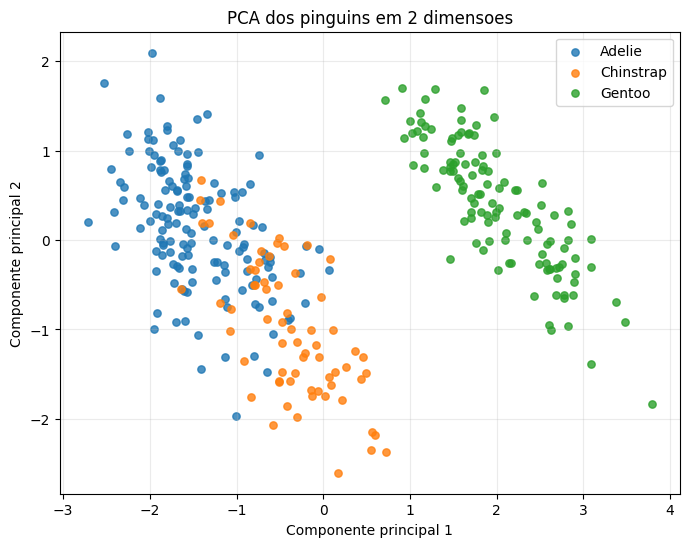

In [45]:
nomes_classes = {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

plt.figure(figsize=(8, 6))
for classe in np.unique(classes_penguins):
    mascara = classes_penguins == classe
    plt.scatter(
        projecao_penguins_2d[mascara, 0],
        projecao_penguins_2d[mascara, 1],
        s=28,
        alpha=0.8,
        label=nomes_classes.get(classe, f'Classe {classe}'),
    )

plt.title('PCA dos pinguins em 2 dimensoes')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Questão B

In [46]:
def variancia_explicada_pca(dados):
    dados_centralizados = dados - dados.mean(axis=0)
    _, valores_singulares, _ = np.linalg.svd(dados_centralizados, full_matrices=False)
    autovalores = (valores_singulares ** 2) / (len(dados) - 1)
    proporcoes = autovalores / autovalores.sum()
    return proporcoes, np.cumsum(proporcoes)


proporcoes_variancia, variancia_acumulada = variancia_explicada_pca(atributos_penguins_norm)

print('Dimensao projetada | Variancia explicada acumulada')
for dimensao in range(1, 5):
    print(f'{dimensao:17d} | {variancia_acumulada[dimensao - 1]:.4f} ({100 * variancia_acumulada[dimensao - 1]:.2f}%)')

Dimensao projetada | Variancia explicada acumulada
                1 | 0.6863 (68.63%)
                2 | 0.8809 (88.09%)
                3 | 0.9730 (97.30%)
                4 | 1.0000 (100.00%)


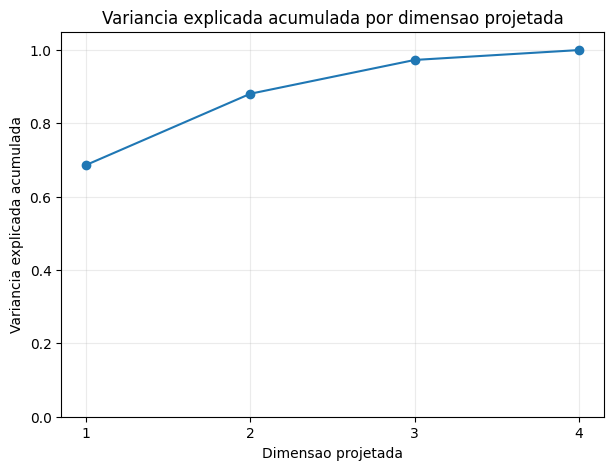

In [47]:
dimensoes = np.arange(1, 5)

plt.figure(figsize=(7, 5))
plt.plot(dimensoes, variancia_acumulada[:4], marker='o')
plt.xticks(dimensoes)
plt.ylim(0, 1.05)
plt.title('Variancia explicada acumulada por dimensao projetada')
plt.xlabel('Dimensao projetada')
plt.ylabel('Variancia explicada acumulada')
plt.grid(alpha=0.25)
plt.show()